In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [2]:
# ~~~~~~~~~~~~~~~~~~setting the table~~~~~~~~~~~~~~~~~~~
# !pip install chart-studio
# !pip install xgboost
# !pip install sklearn
# !pip install plotly
# !pip install scipy

In [3]:
# importing libraries for data handling and analysis
import pandas as pd
from pandas.plotting import scatter_matrix
from pandas import ExcelWriter
from pandas import ExcelFile
from openpyxl import load_workbook
import numpy as np
from scipy.stats import norm, skew
from scipy import stats
import statsmodels.api as sm

In [4]:
# importing libraries for data visualisations
import seaborn as sns
from matplotlib import pyplot
import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib
%matplotlib inline
color = sns.color_palette()
from IPython.display import display
pd.options.display.max_columns = None
# Standard plotly imports
import chart_studio
import chart_studio.plotly as py
import plotly.figure_factory as ff
import plotly.graph_objs as go
from plotly.offline import iplot, init_notebook_mode
# Using plotly + cufflinks in offline mode
from plotly.offline import download_plotlyjs, init_notebook_mode, plot, iplot
import cufflinks as cf
cf.set_config_file(offline=True)
import cufflinks
cufflinks.go_offline(connected=True)
init_notebook_mode(connected=True)

In [5]:
# sklearn modules for preprocessing
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
# from imblearn.over_sampling import SMOTE  # SMOTE
# sklearn modules for ML model selection
from sklearn.model_selection import train_test_split  # import 'train_test_split'
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score

# Libraries for data modelling
from sklearn import svm, tree, linear_model, neighbors
from sklearn import naive_bayes, ensemble, discriminant_analysis, gaussian_process
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

# Common sklearn Model Helpers
from sklearn import feature_selection
from sklearn import model_selection
from sklearn import metrics
# from sklearn.datasets import make_classification

# sklearn modules for performance metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
from sklearn.metrics import auc, roc_auc_score, roc_curve, recall_score, log_loss
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, make_scorer
from sklearn.metrics import average_precision_score

In [6]:
# importing misceallenous libraries
import os
import re
import sys
import timeit
import string
from datetime import datetime
from time import time
from dateutil.parser import parse
# ip = get_ipython()
# ip.register_magics(jupyternotify.JupyterNotifyMagics)

DATA IMPORT AND DF LEFT JOINS TO CREATE SINGLE TABLE.

In [7]:
# Load source data
df_sourcefile = pd.read_csv('data/employee_main_file.csv')
print("Shape of dataframe is: {}".format(df_sourcefile.shape))

Shape of dataframe is: (2001, 20)


In [8]:
# Make a copy of the original sourcefile
df_HR1 = df_sourcefile.copy()

In [9]:
df_sourcefile = pd.read_csv('data/employee_performance_evals.csv')
print("Shape of dataframe is: {}".format(df_sourcefile.shape))

Shape of dataframe is: (8486, 3)


In [10]:
# Make a copy of the original sourcefile
df_HR2 = df_sourcefile.copy()

In [11]:
df_sourcefile = pd.read_csv('data/employee_workplace_sat_scores.csv')
print("Shape of dataframe is: {}".format(df_sourcefile.shape))

Shape of dataframe is: (8004, 4)


In [12]:
# Make a copy of the original sourcefile
df_HR3 = df_sourcefile.copy()

In [13]:
df_HR1.head()

,EmployeeId,CommuteDistance,DegreeCompleted,DegreeField,Department,EmploymentEndDate,EmploymentEndReason,EmploymentStartDate,Gender,JobLevel,MaritalStatus,NumPreviousCompanies,NumYearsWorked,OvertimeDays,OvertimeHours,Salary,TrainingsAttended,TravelFrequency,WeeklyHoursBudgeted,YearOfBirth
0,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980
1,1002,7,Master,Other,Other,NaT,NaN,2017-10-10,Female,2,Single,2.0,12,1,5,60400,1,Monthly,40,1986
2,1003,9,Bachelor,Business,Other,2019-03-08,Retired,2014-07-23,Male,2,Married,NaN,5,4,15,49100,2,No travel,40,1992
3,1004,8,Master,Other,Marketing,NaT,NaN,2014-05-08,Male,2,Single,1.0,15,1,3,47100,0,No travel,40,1979
4,1005,7,Master,Computer Science,Marketing,NaT,NaN,2013-12-24,Male,4,Single,2.0,16,4,12,58700,1,Monthly,40,1979


In [14]:
df_HR2.head()

,EmployeeId,ReviewDate,PerformanceRating
0,1001,2015-12-14,3
1,1001,2016-12-13,3
2,1001,2017-12-13,3
3,1001,2018-12-13,3
4,1001,2019-12-13,3


In [15]:
df_HR3.head()

,EmployeeId,QuestionNum,QuestionText,Response
0,1001,Q1,How satisfied are you with your job?,Very Satisfied
1,1001,Q2,How satisfied are you with the company?,Neither Satisfied nor Unsatisfied
2,1001,Q3,How satisfied are you with your manager?,Somewhat Satisfied
3,1001,Q4,How would you rate you work/life balance?,Excellent
4,1002,Q1,How satisfied are you with your job?,Very Satisfied


In [16]:
combo_df_step = df_HR1.merge(df_HR2, on='EmployeeId', how='left')

In [17]:
combo_df_step.head()

,EmployeeId,CommuteDistance,DegreeCompleted,DegreeField,Department,EmploymentEndDate,EmploymentEndReason,EmploymentStartDate,Gender,JobLevel,MaritalStatus,NumPreviousCompanies,NumYearsWorked,OvertimeDays,OvertimeHours,Salary,TrainingsAttended,TravelFrequency,WeeklyHoursBudgeted,YearOfBirth,ReviewDate,PerformanceRating
0,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0
1,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2016-12-13,3.0
2,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2017-12-13,3.0
3,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2018-12-13,3.0
4,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2019-12-13,3.0


In [18]:
combo_df= combo_df_step.merge(df_HR3, on='EmployeeId', how='left')

In [19]:
combo_df.head()

,EmployeeId,CommuteDistance,DegreeCompleted,DegreeField,Department,EmploymentEndDate,EmploymentEndReason,EmploymentStartDate,Gender,JobLevel,MaritalStatus,NumPreviousCompanies,NumYearsWorked,OvertimeDays,OvertimeHours,Salary,TrainingsAttended,TravelFrequency,WeeklyHoursBudgeted,YearOfBirth,ReviewDate,PerformanceRating,QuestionNum,QuestionText,Response
0,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q1,How satisfied are you with your job?,Very Satisfied
1,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q2,How satisfied are you with the company?,Neither Satisfied nor Unsatisfied
2,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q3,How satisfied are you with your manager?,Somewhat Satisfied
3,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q4,How would you rate you work/life balance?,Excellent
4,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2016-12-13,3.0,Q1,How satisfied are you with your job?,Very Satisfied


In [20]:
# Dataset columns
combo_df.columns

Index(['EmployeeId', 'CommuteDistance', 'DegreeCompleted', 'DegreeField',
       'Department', 'EmploymentEndDate', 'EmploymentEndReason',
       'EmploymentStartDate', 'Gender', 'JobLevel', 'MaritalStatus',
       'NumPreviousCompanies', 'NumYearsWorked', 'OvertimeDays',
       'OvertimeHours', 'Salary', 'TrainingsAttended', 'TravelFrequency',
       'WeeklyHoursBudgeted', 'YearOfBirth', 'ReviewDate', 'PerformanceRating',
       'QuestionNum', 'QuestionText', 'Response'],
      dtype='object')

In [21]:
# Dataset header
combo_df.head()

,EmployeeId,CommuteDistance,DegreeCompleted,DegreeField,Department,EmploymentEndDate,EmploymentEndReason,EmploymentStartDate,Gender,JobLevel,MaritalStatus,NumPreviousCompanies,NumYearsWorked,OvertimeDays,OvertimeHours,Salary,TrainingsAttended,TravelFrequency,WeeklyHoursBudgeted,YearOfBirth,ReviewDate,PerformanceRating,QuestionNum,QuestionText,Response
0,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q1,How satisfied are you with your job?,Very Satisfied
1,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q2,How satisfied are you with the company?,Neither Satisfied nor Unsatisfied
2,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q3,How satisfied are you with your manager?,Somewhat Satisfied
3,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2015-12-14,3.0,Q4,How would you rate you work/life balance?,Excellent
4,1001,10,Master,Business,Accounting,NaT,NaN,2014-12-12,Female,4,Married,2.0,13,1,2,96800,0,None,40,1980,2016-12-13,3.0,Q1,How satisfied are you with your job?,Very Satisfied


In [22]:
combo_df.columns.to_series().groupby(combo_df.dtypes).groups

{int64: ['CommuteDistance', 'JobLevel', 'NumYearsWorked', 'OvertimeDays', 'OvertimeHours', 'Salary', 'TrainingsAttended', 'WeeklyHoursBudgeted', 'YearOfBirth'], datetime64[ns]: ['EmploymentEndDate', 'EmploymentStartDate', 'ReviewDate'], float64: ['NumPreviousCompanies', 'PerformanceRating'], object: ['EmployeeId', 'DegreeCompleted', 'DegreeField', 'Department', 'EmploymentEndReason', 'Gender', 'MaritalStatus', 'TravelFrequency', 'QuestionNum', 'QuestionText', 'Response']}

In [23]:
# Columns datatypes and missign values
combo_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18737 entries, 0 to 18736
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   EmployeeId            18737 non-null  object        
 1   CommuteDistance       18737 non-null  int64         
 2   DegreeCompleted       18737 non-null  object        
 3   DegreeField           18614 non-null  object        
 4   Department            18737 non-null  object        
 5   EmploymentEndDate     8654 non-null   datetime64[ns]
 6   EmploymentEndReason   8654 non-null   object        
 7   EmploymentStartDate   18737 non-null  datetime64[ns]
 8   Gender                18737 non-null  object        
 9   JobLevel              18737 non-null  int64         
 10  MaritalStatus         18102 non-null  object        
 11  NumPreviousCompanies  13534 non-null  float64       
 12  NumYearsWorked        18737 non-null  int64         
 13  OvertimeDays    

In [24]:
combo_df.describe()

,CommuteDistance,JobLevel,NumPreviousCompanies,NumYearsWorked,OvertimeDays,OvertimeHours,Salary,TrainingsAttended,WeeklyHoursBudgeted,YearOfBirth,PerformanceRating
count,18737.000000,18737.000000,13534.000000,18737.000000,18737.000000,18737.000000,18737.000000,18737.000000,18737.0,18737.000000,17993.000000
mean,9.614399,2.385707,1.802719,19.071836,3.808400,9.060735,77525.585739,1.382986,40.0,1976.451406,3.302395
std,4.052054,1.118785,1.452905,9.548427,4.857679,7.667441,35700.375550,1.051962,0.0,9.538575,0.838891
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,22700.000000,-1.000000,40.0,1949.000000,1.000000
25%,7.000000,2.000000,1.000000,12.000000,1.000000,4.000000,51700.000000,1.000000,40.0,1970.000000,3.000000
50%,9.000000,2.000000,2.000000,19.000000,2.000000,7.000000,69500.000000,1.000000,40.0,1977.000000,3.000000
75%,13.000000,3.000000,3.000000,26.000000,5.000000,12.000000,94700.000000,2.000000,40.0,1984.000000,4.000000
max,25.000000,5.000000,10.000000,49.000000,57.000000,78.000000,258300.000000,8.000000,40.0,1995.000000,5.000000


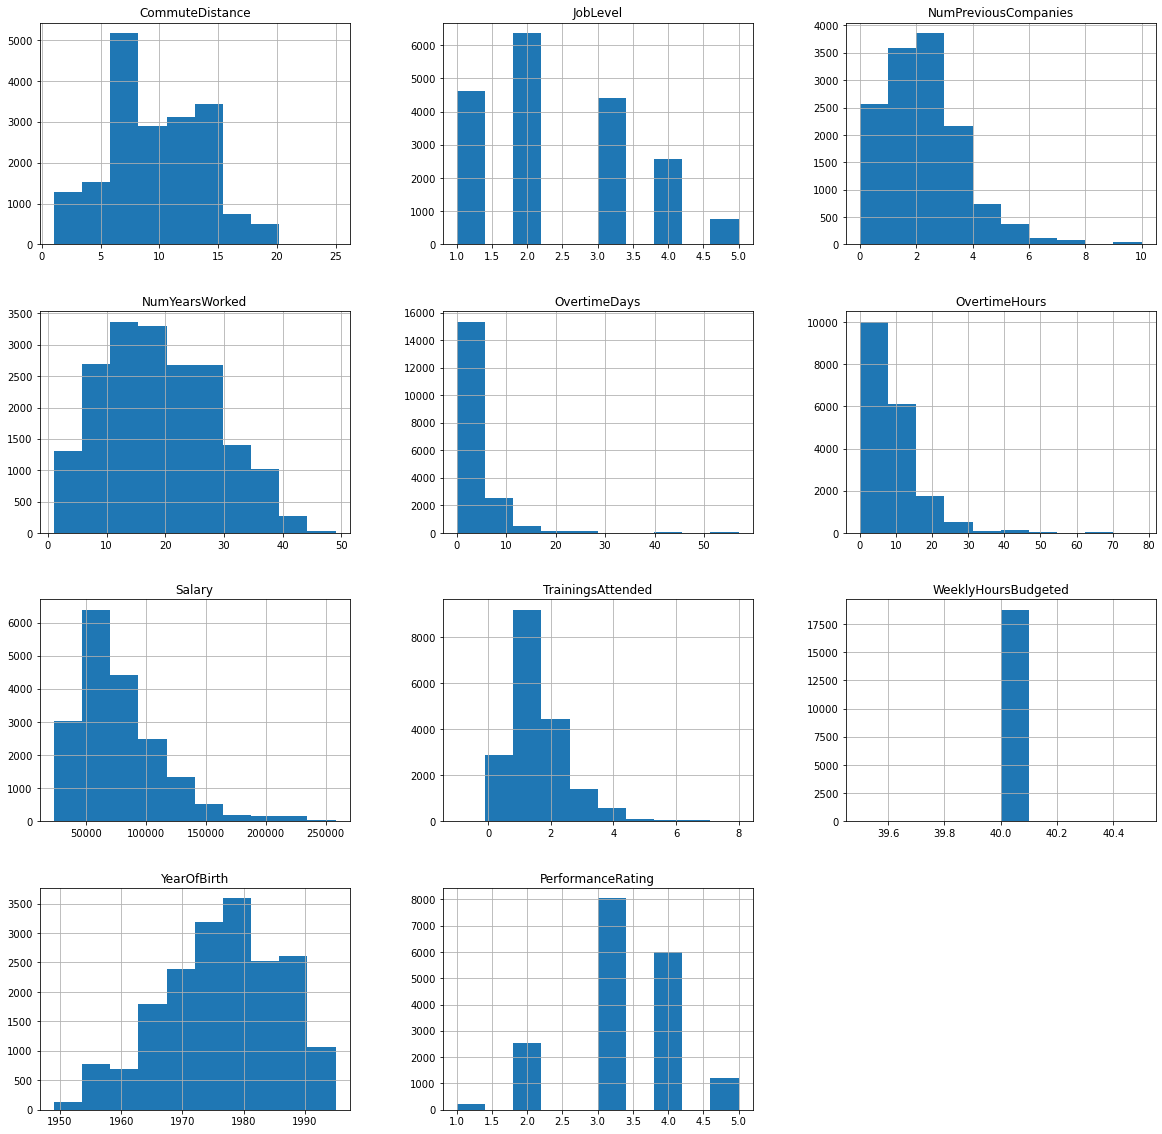

In [25]:
combo_df.hist(figsize=(20,20))
plt.show()

In [26]:
(mu, sigma) = norm.fit(combo_df.loc[combo_df['Attrition'] == 'Yes', 'Age'])
print(
    'Ex-exmployees: average age = {:.1f} years old and standard deviation = {:.1f}'.format(mu, sigma))
(mu, sigma) = norm.fit(combo_df.loc[combo_df['Attrition'] == 'No', 'Age'])
print('Current exmployees: average age = {:.1f} years old and standard deviation = {:.1f}'.format(
    mu, sigma))

KeyError: 'Attrition'

In [27]:
# Add histogram data
x1 = combo_df.loc[combo_df['Attrition'] == 'No', 'Age']
x2 = combo_df.loc[combo_df['Attrition'] == 'Yes', 'Age']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Age Distribution in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[15, 60], dtick=5))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

KeyError: 'Attrition'

In [ ]:
# Education Field of employees
combo_df['EducationField'].value_counts()

In [ ]:
df_EducationField = pd.DataFrame(columns=["Field", "% of Leavers"])
i=0
for field in list(combo_df['EducationField'].unique()):
    ratio = combo_df[(combo_df['EducationField']==field)&(combo_df['Attrition']=="Yes")].shape[0] / combo_df[combo_df['EducationField']==field].shape[0]
    df_EducationField.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_EF = df_EducationField.groupby(by="Field").sum()
df_EF.iplot(kind='bar',title='Leavers by Education Field (%)')

In [ ]:
# Gender of employees
df_HR['Gender'].value_counts()

In [ ]:
print("Normalised gender distribution of ex-employees in the dataset: Male = {:.1f}%; Female {:.1f}%.".format((df_HR[(df_HR['Attrition'] == 'Yes') & (
    df_HR['Gender'] == 'Male')].shape[0] / df_HR[df_HR['Gender'] == 'Male'].shape[0])*100, (df_HR[(df_HR['Attrition'] == 'Yes') & (df_HR['Gender'] == 'Female')].shape[0] / df_HR[df_HR['Gender'] == 'Female'].shape[0])*100))

In [ ]:
df_Gender = pd.DataFrame(columns=["Gender", "% of Leavers"])
i=0
for field in list(df_HR['Gender'].unique()):
    ratio = df_HR[(df_HR['Gender']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['Gender']==field].shape[0]
    df_Gender.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_G = df_Gender.groupby(by="Gender").sum()
df_G.iplot(kind='bar',title='Leavers by Gender (%)')

In [ ]:
# Marital Status of employees
df_HR['MaritalStatus'].value_counts()

In [ ]:
df_Marital = pd.DataFrame(columns=["Marital Status", "% of Leavers"])
i=0
for field in list(df_HR['MaritalStatus'].unique()):
    ratio = df_HR[(df_HR['MaritalStatus']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['MaritalStatus']==field].shape[0]
    df_Marital.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_MF = df_Marital.groupby(by="Marital Status").sum()
df_MF.iplot(kind='bar',title='Leavers by Marital Status (%)')

In [ ]:
# Distance from Home
print("Distance from home for employees to get to work is from {} to {} miles.".format(df_HR['DistanceFromHome'].min(),
                                                                                       df_HR['DistanceFromHome'].max()))

In [ ]:
print('Average distance from home for currently active employees: {:.2f} miles and ex-employees: {:.2f} miles'.format(
    df_HR[df_HR['Attrition'] == 'No']['DistanceFromHome'].mean(), df_HR[df_HR['Attrition'] == 'Yes']['DistanceFromHome'].mean()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'DistanceFromHome']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'DistanceFromHome']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(
    title='Distance From Home Distribution in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 30], dtick=2))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
# The organisation consists of several departments
df_HR['Department'].value_counts()

In [ ]:
df_Department = pd.DataFrame(columns=["Department", "% of Leavers"])
i=0
for field in list(df_HR['Department'].unique()):
    ratio = df_HR[(df_HR['Department']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['Department']==field].shape[0]
    df_Department.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_DF = df_Department.groupby(by="Department").sum()
df_DF.iplot(kind='bar',title='Leavers by Department (%)')

In [ ]:
# Employees have different business travel commitmnent depending on their roles and level in the organisation
df_HR['BusinessTravel'].value_counts()

In [ ]:
df_BusinessTravel = pd.DataFrame(columns=["Business Travel", "% of Leavers"])
i=0
for field in list(df_HR['BusinessTravel'].unique()):
    ratio = df_HR[(df_HR['BusinessTravel']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['BusinessTravel']==field].shape[0]
    df_BusinessTravel.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_BT = df_BusinessTravel.groupby(by="Business Travel").sum()
df_BT.iplot(kind='bar',title='Leavers by Business Travel (%)')

In [ ]:
# Employees in the database have several roles on-file
df_HR['JobRole'].value_counts()

In [ ]:
df_JobRole = pd.DataFrame(columns=["Job Role", "% of Leavers"])
i=0
for field in list(df_HR['JobRole'].unique()):
    ratio = df_HR[(df_HR['JobRole']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['JobRole']==field].shape[0]
    df_JobRole.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_JR = df_JobRole.groupby(by="Job Role").sum()
df_JR.iplot(kind='bar',title='Leavers by Job Role (%)')

In [ ]:
df_HR['JobLevel'].value_counts()

In [ ]:
df_JobLevel = pd.DataFrame(columns=["Job Level", "% of Leavers"])
i=0
for field in list(df_HR['JobLevel'].unique()):
    ratio = df_HR[(df_HR['JobLevel']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['JobLevel']==field].shape[0]
    df_JobLevel.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_JL = df_JobLevel.groupby(by="Job Level").sum()
df_JL.iplot(kind='bar',title='Leavers by Job Level (%)')

In [ ]:
df_HR['JobInvolvement'].value_counts()

In [ ]:
df_JobInvolvement = pd.DataFrame(columns=["Job Involvement", "% of Leavers"])
i=0
for field in list(df_HR['JobInvolvement'].unique()):
    ratio = df_HR[(df_HR['JobInvolvement']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['JobInvolvement']==field].shape[0]
    df_JobInvolvement.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_JI = df_JobInvolvement.groupby(by="Job Involvement").sum()
df_JI.iplot(kind='bar',title='Leavers by Job Involvement (%)')

In [ ]:
print("Number of training times last year varies from {} to {} years.".format(
    df_HR['TrainingTimesLastYear'].min(), df_HR['TrainingTimesLastYear'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'TrainingTimesLastYear']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'TrainingTimesLastYear']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(
    title='Training Times Last Year metric in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 6], dtick=1))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
df_HR['NumCompaniesWorked'].value_counts()

In [ ]:
df_NumCompaniesWorked = pd.DataFrame(columns=["Num Companies Worked", "% of Leavers"])
i=0
for field in list(df_HR['NumCompaniesWorked'].unique()):
    ratio = df_HR[(df_HR['NumCompaniesWorked']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['NumCompaniesWorked']==field].shape[0]
    df_NumCompaniesWorked.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_NC = df_NumCompaniesWorked.groupby(by="Num Companies Worked").sum()
df_NC.iplot(kind='bar',title='Leavers by Num Companies Worked (%)')

In [ ]:
df_HR

In [ ]:
print('Average Number of Years at the company for currently active employees: {:.2f} miles and ex-employees: {:.2f} years'.format(
    df_HR[df_HR['Attrition'] == 'No']['YearsAtCompany'].mean(), df_HR[df_HR['Attrition'] == 'Yes']['YearsAtCompany'].mean()))

In [ ]:
print("Number of Years at the company varies from {} to {} years.".format(
    df_HR['YearsAtCompany'].min(), df_HR['YearsAtCompany'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'YearsAtCompany']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'YearsAtCompany']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Years At Company in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 40], dtick=5))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
print("Number of Years in the current role varies from {} to {} years.".format(
    df_HR['YearsInCurrentRole'].min(), df_HR['YearsInCurrentRole'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'YearsInCurrentRole']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'YearsInCurrentRole']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Years InCurrent Role in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 18], dtick=1))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
print("Number of Years since last promotion varies from {} to {} years.".format(
    df_HR['YearsSinceLastPromotion'].min(), df_HR['YearsSinceLastPromotion'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'YearsSinceLastPromotion']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'YearsSinceLastPromotion']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Years Since Last Promotion in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 15], dtick=1))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
print("Total working years varies from {} to {} years.".format(
    df_HR['TotalWorkingYears'].min(), df_HR['TotalWorkingYears'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'TotalWorkingYears']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'TotalWorkingYears']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Total Working Years in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 40], dtick=5))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
print('Average Number of Years wit current manager for currently active employees: {:.2f} miles and ex-employees: {:.2f} years'.format(
    df_HR[df_HR['Attrition'] == 'No']['YearsWithCurrManager'].mean(), df_HR[df_HR['Attrition'] == 'Yes']['YearsWithCurrManager'].mean()))

In [ ]:
print("Number of Years wit current manager varies from {} to {} years.".format(
    df_HR['YearsWithCurrManager'].min(), df_HR['YearsWithCurrManager'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'YearsWithCurrManager']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'YearsWithCurrManager']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(
    title='Years With Curr Manager in Percent by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 17], dtick=1))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
df_HR['WorkLifeBalance'].value_counts()

In [ ]:
df_WorkLifeBalance = pd.DataFrame(columns=["WorkLifeBalance", "% of Leavers"])
i=0
for field in list(df_HR['WorkLifeBalance'].unique()):
    ratio = df_HR[(df_HR['WorkLifeBalance']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['WorkLifeBalance']==field].shape[0]
    df_WorkLifeBalance.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_WLB = df_WorkLifeBalance.groupby(by="WorkLifeBalance").sum()
df_WLB.iplot(kind='bar',title='Leavers by WorkLifeBalance (%)')

In [ ]:
df_HR['StandardHours'].value_counts()

In [ ]:
df_HR['OverTime'].value_counts()

In [ ]:
df_OverTime = pd.DataFrame(columns=["OverTime", "% of Leavers"])
i=0
for field in list(df_HR['OverTime'].unique()):
    ratio = df_HR[(df_HR['OverTime']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['OverTime']==field].shape[0]
    df_OverTime.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_OT = df_OverTime.groupby(by="OverTime").sum()
df_OT.iplot(kind='bar',title='Leavers by OverTime (%)')

In [ ]:
print("Employee Hourly Rate varies from ${} to ${}.".format(
    df_HR['HourlyRate'].min(), df_HR['HourlyRate'].max()))

In [ ]:
print("Employee Daily Rate varies from ${} to ${}.".format(
    df_HR['DailyRate'].min(), df_HR['DailyRate'].max()))

In [ ]:
print("Employee Monthly Rate varies from ${} to ${}.".format(
    df_HR['MonthlyRate'].min(), df_HR['MonthlyRate'].max()))

In [ ]:
print("Employee Monthly Income varies from ${} to ${}.".format(
    df_HR['MonthlyIncome'].min(), df_HR['MonthlyIncome'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'MonthlyIncome']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'MonthlyIncome']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Monthly Income by Attrition Status')
fig['layout'].update(xaxis=dict(range=[0, 20000], dtick=2000))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
print("Percentage Salary Hikes varies from {}% to {}%.".format(
    df_HR['PercentSalaryHike'].min(), df_HR['PercentSalaryHike'].max()))

In [ ]:
# Add histogram data
x1 = df_HR.loc[df_HR['Attrition'] == 'No', 'PercentSalaryHike']
x2 = df_HR.loc[df_HR['Attrition'] == 'Yes', 'PercentSalaryHike']
# Group data together
hist_data = [x1, x2]
group_labels = ['Active Employees', 'Ex-Employees']
# Create distplot with custom bin_size
fig = ff.create_distplot(hist_data, group_labels,
                         curve_type='kde', show_hist=False, show_rug=False)
# Add title
fig['layout'].update(title='Percent Salary Hike by Attrition Status')
fig['layout'].update(xaxis=dict(range=[10, 26], dtick=1))
# Plot
py.iplot(fig, filename='Distplot with Multiple Datasets')

In [ ]:
print("Stock Option Levels varies from {} to {}.".format(
    df_HR['StockOptionLevel'].min(), df_HR['StockOptionLevel'].max()))

In [ ]:
print("Normalised percentage of leavers by Stock Option Level: 1: {:.2f}%, 2: {:.2f}%, 3: {:.2f}%".format(
    df_HR[(df_HR['Attrition'] == 'Yes') & (df_HR['StockOptionLevel'] == 1)
          ].shape[0] / df_HR[df_HR['StockOptionLevel'] == 1].shape[0]*100,
    df_HR[(df_HR['Attrition'] == 'Yes') & (df_HR['StockOptionLevel'] == 2)
          ].shape[0] / df_HR[df_HR['StockOptionLevel'] == 1].shape[0]*100,
    df_HR[(df_HR['Attrition'] == 'Yes') & (df_HR['StockOptionLevel'] == 3)].shape[0] / df_HR[df_HR['StockOptionLevel'] == 1].shape[0]*100))

In [ ]:
df_StockOptionLevel = pd.DataFrame(columns=["StockOptionLevel", "% of Leavers"])
i=0
for field in list(df_HR['StockOptionLevel'].unique()):
    ratio = df_HR[(df_HR['StockOptionLevel']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['StockOptionLevel']==field].shape[0]
    df_StockOptionLevel.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_SOL = df_StockOptionLevel.groupby(by="StockOptionLevel").sum()
df_SOL.iplot(kind='bar',title='Leavers by Stock Option Level (%)')

In [ ]:
df_HR['EnvironmentSatisfaction'].value_counts()

In [ ]:
df_EnvironmentSatisfaction = pd.DataFrame(columns=["EnvironmentSatisfaction", "% of Leavers"])
i=0
for field in list(df_HR['EnvironmentSatisfaction'].unique()):
    ratio = df_HR[(df_HR['EnvironmentSatisfaction']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['EnvironmentSatisfaction']==field].shape[0]
    df_EnvironmentSatisfaction.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_Env = df_EnvironmentSatisfaction.groupby(by="EnvironmentSatisfaction").sum()
df_Env.iplot(kind='bar',title='Leavers by Environment Satisfaction (%)')

In [ ]:
# Job Satisfaction was captured as: 1 'Low' 2 'Medium' 3 'High' 4 'Very High'
df_HR['JobSatisfaction'].value_counts()

In [ ]:
df_JobSatisfaction = pd.DataFrame(columns=["JobSatisfaction", "% of Leavers"])
i=0
for field in list(df_HR['JobSatisfaction'].unique()):
    ratio = df_HR[(df_HR['JobSatisfaction']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['JobSatisfaction']==field].shape[0]
    df_JobSatisfaction.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_JS = df_JobSatisfaction.groupby(by="JobSatisfaction").sum()
df_JS.iplot(kind='bar',title='Leavers by Job Satisfaction (%)')

In [ ]:
df_HR['RelationshipSatisfaction'].value_counts()

In [ ]:
df_RelationshipSatisfaction = pd.DataFrame(columns=["RelationshipSatisfaction", "% of Leavers"])
i=0
for field in list(df_HR['RelationshipSatisfaction'].unique()):
    ratio = df_HR[(df_HR['RelationshipSatisfaction']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['RelationshipSatisfaction']==field].shape[0]
    df_RelationshipSatisfaction.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_RS = df_RelationshipSatisfaction.groupby(by="RelationshipSatisfaction").sum()
df_RS.iplot(kind='bar',title='Leavers by Relationship Satisfaction (%)')

In [ ]:
df_HR['PerformanceRating'].value_counts()

In [ ]:
print("Normalised percentage of leavers by Stock Option Level: 3: {:.2f}%, 4: {:.2f}%".format(
    df_HR[(df_HR['Attrition'] == 'Yes') & (df_HR['PerformanceRating'] == 3)
          ].shape[0] / df_HR[df_HR['StockOptionLevel'] == 1].shape[0]*100,
    df_HR[(df_HR['Attrition'] == 'Yes') & (df_HR['PerformanceRating'] == 4)].shape[0] / df_HR[df_HR['StockOptionLevel'] == 1].shape[0]*100))

In [ ]:
df_PerformanceRating = pd.DataFrame(columns=["PerformanceRating", "% of Leavers"])
i=0
for field in list(df_HR['PerformanceRating'].unique()):
    ratio = df_HR[(df_HR['PerformanceRating']==field)&(df_HR['Attrition']=="Yes")].shape[0] / df_HR[df_HR['PerformanceRating']==field].shape[0]
    df_PerformanceRating.loc[i] = (field, ratio*100)
    i += 1
    #print("In {}, the ratio of leavers is {:.2f}%".format(field, ratio*100))    
df_PR = df_PerformanceRating.groupby(by="PerformanceRating").sum()
df_PR.iplot(kind='bar',title='Leavers by Performance Rating (%)')

In [ ]:
# Attrition indicates if the employee is currently active ('No') or has left the company ('Yes')
df_HR['Attrition'].value_counts()

In [ ]:
print("Percentage of Current Employees is {:.1f}% and of Ex-employees is: {:.1f}%".format(
    df_HR[df_HR['Attrition'] == 'No'].shape[0] / df_HR.shape[0]*100,
    df_HR[df_HR['Attrition'] == 'Yes'].shape[0] / df_HR.shape[0]*100))

In [ ]:
df_HR['Attrition'].iplot(kind='hist', xTitle='Attrition',
                         yTitle='count', title='Attrition Distribution')

In [ ]:
# Find correlations with the target and sort
df_HR_trans = df_HR.copy()
df_HR_trans['Target'] = df_HR_trans['Attrition'].apply(
    lambda x: 0 if x == 'No' else 1)
df_HR_trans = df_HR_trans.drop(
    ['Attrition', 'EmployeeCount', 'EmployeeNumber', 'StandardHours', 'Over18'], axis=1)
correlations = df_HR_trans.corr()['Target'].sort_values()
print('Most Positive Correlations: \n', correlations.tail(5))
print('\nMost Negative Correlations: \n', correlations.head(5))

In [ ]:
# Calculate correlations
corr = df_HR_trans.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask)] = True
# Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr,
            vmax=.5,
            mask=mask,
            # annot=True, fmt='.2f',
            linewidths=.2, cmap="YlGnBu")

In [ ]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
# Create a label encoder object
le = LabelEncoder()

In [ ]:
print(df_HR.shape)
df_HR.head()

In [ ]:
# Label Encoding will be used for columns with 2 or less unique values
le_count = 0
for col in df_HR.columns[1:]:
    if df_HR[col].dtype == 'object':
        if len(list(df_HR[col].unique())) <= 2:
            le.fit(df_HR[col])
            df_HR[col] = le.transform(df_HR[col])
            le_count += 1
print('{} columns were label encoded.'.format(le_count))

In [ ]:
# convert rest of categorical variable into dummy
df_HR = pd.get_dummies(df_HR, drop_first=True)

In [ ]:
# import MinMaxScaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 5))
HR_col = list(df_HR.columns)
HR_col.remove('Attrition')
for col in HR_col:
    df_HR[col] = df_HR[col].astype(float)
    df_HR[[col]] = scaler.fit_transform(df_HR[[col]])
df_HR['Attrition'] = pd.to_numeric(df_HR['Attrition'], downcast='float')
df_HR.head()

In [ ]:
print('Size of Full Encoded Dataset: {}'. format(df_HR.shape))

In [ ]:
# assign the target to a new dataframe and convert it to a numerical feature
#df_target = df_HR[['Attrition']].copy()
target = df_HR['Attrition'].copy()

In [ ]:
type(target)

In [ ]:
# let's remove the target feature and redundant features from the dataset
df_HR.drop(['Attrition', 'EmployeeCount', 'EmployeeNumber',
            'StandardHours', 'Over18'], axis=1, inplace=True)
print('Size of Full dataset is: {}'.format(df_HR.shape))

In [ ]:
# Since we have class imbalance (i.e. more employees with turnover=0 than turnover=1)
# let's use stratify=y to maintain the same ratio as in the training dataset when splitting the dataset
X_train, X_test, y_train, y_test = train_test_split(df_HR,
                                                    target,
                                                    test_size=0.25,
                                                    random_state=7,
                                                    stratify=target)  
print("Number transactions X_train dataset: ", X_train.shape)
print("Number transactions y_train dataset: ", y_train.shape)
print("Number transactions X_test dataset: ", X_test.shape)
print("Number transactions y_test dataset: ", y_test.shape)

In [ ]:
# selection of algorithms to consider and set performance measure
models = []
models.append(('Logistic Regression', LogisticRegression(solver='liblinear', random_state=7,
                                                         class_weight='balanced')))
models.append(('Random Forest', RandomForestClassifier(
    n_estimators=100, random_state=7)))
models.append(('SVM', SVC(gamma='auto', random_state=7)))
models.append(('KNN', KNeighborsClassifier()))
models.append(('Decision Tree Classifier',
               DecisionTreeClassifier(random_state=7)))
models.append(('Gaussian NB', GaussianNB()))

In [ ]:
acc_results = []
auc_results = []
names = []
# set table to table to populate with performance results
col = ['Algorithm', 'ROC AUC Mean', 'ROC AUC STD', 
       'Accuracy Mean', 'Accuracy STD']
df_results = pd.DataFrame(columns=col)
i = 0
# evaluate each model using cross-validation
for name, model in models:
    kfold = model_selection.KFold(
        n_splits=10, random_state=7)  # 10-fold cross-validation

    cv_acc_results = model_selection.cross_val_score(  # accuracy scoring
        model, X_train, y_train, cv=kfold, scoring='accuracy')

    cv_auc_results = model_selection.cross_val_score(  # roc_auc scoring
        model, X_train, y_train, cv=kfold, scoring='roc_auc')

    acc_results.append(cv_acc_results)
    auc_results.append(cv_auc_results)
    names.append(name)
    df_results.loc[i] = [name,
                         round(cv_auc_results.mean()*100, 2),
                         round(cv_auc_results.std()*100, 2),
                         round(cv_acc_results.mean()*100, 2),
                         round(cv_acc_results.std()*100, 2)
                         ]
    i += 1
df_results.sort_values(by=['ROC AUC Mean'], ascending=False)

In [ ]:
fig = plt.figure(figsize=(15, 7))
fig.suptitle('Algorithm Accuracy Comparison')
ax = fig.add_subplot(111)
plt.boxplot(acc_results)
ax.set_xticklabels(names)
plt.show()

In [ ]:
fig = plt.figure(figsize=(15, 7))
fig.suptitle('Algorithm ROC AUC Comparison')
ax = fig.add_subplot(111)
plt.boxplot(auc_results)
ax.set_xticklabels(names)
plt.show()

Logistic Regression
Let's take a closer look at using the Logistic Regression algorithm. I'll be using 10 fold Cross-Validation to train our Logistic Regression Model and estimate its AUC score.

In [ ]:
kfold = model_selection.KFold(n_splits=10, random_state=7)
modelCV = LogisticRegression(solver='liblinear',
                             class_weight="balanced", 
                             random_state=7)
scoring = 'roc_auc'
results = model_selection.cross_val_score(
    modelCV, X_train, y_train, cv=kfold, scoring=scoring)
print("AUC score (STD): %.2f (%.2f)" % (results.mean(), results.std()))

In [ ]:
param_grid = {'C': np.arange(1e-03, 2, 0.01)} # hyper-parameter list to fine-tune
log_gs = GridSearchCV(LogisticRegression(solver='liblinear', # setting GridSearchCV
                                         class_weight="balanced", 
                                         random_state=7),
                      iid=True,
                      return_train_score=True,
                      param_grid=param_grid,
                      scoring='roc_auc',
                      cv=10)

log_grid = log_gs.fit(X_train, y_train)
log_opt = log_grid.best_estimator_
results = log_gs.cv_results_

print('='*20)
print("best params: " + str(log_gs.best_estimator_))
print("best params: " + str(log_gs.best_params_))
print('best score:', log_gs.best_score_)
print('='*20)

In [ ]:
## Confusion Matrix
cnf_matrix = metrics.confusion_matrix(y_test, log_opt.predict(X_test))
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
print('Accuracy of Logistic Regression Classifier on test set: {:.2f}'.format(log_opt.score(X_test, y_test)*100))

In [ ]:
# Classification report for the optimised Log Regression
log_opt.fit(X_train, y_train)
print(classification_report(y_test, log_opt.predict(X_test)))

In [ ]:
log_opt.fit(X_train, y_train) # fit optimised model to the training data
probs = log_opt.predict_proba(X_test) # predict probabilities
probs = probs[:, 1] # we will only keep probabilities associated with the employee leaving
logit_roc_auc = roc_auc_score(y_test, probs) # calculate AUC score using test dataset
print('AUC score: %.3f' % logit_roc_auc)

Random Forest Classifier
Let's take a closer look at using the Random Forest algorithm. I'll fine-tune the Random Forest algorithm's hyper-parameters by cross-validation against the AUC score.

In [ ]:
rf_classifier = RandomForestClassifier(class_weight = "balanced",
                                       random_state=7)
param_grid = {'n_estimators': [50, 75, 100, 125, 150, 175],
              'min_samples_split':[2,4,6,8,10],
              'min_samples_leaf': [1, 2, 3, 4],
              'max_depth': [5, 10, 15, 20, 25]}

grid_obj = GridSearchCV(rf_classifier,
                        iid=True,
                        return_train_score=True,
                        param_grid=param_grid,
                        scoring='roc_auc',
                        cv=10)

grid_fit = grid_obj.fit(X_train, y_train)
rf_opt = grid_fit.best_estimator_

print('='*20)
print("best params: " + str(grid_obj.best_estimator_))
print("best params: " + str(grid_obj.best_params_))
print('best score:', grid_obj.best_score_)
print('='*20)

In [ ]:
importances = rf_opt.feature_importances_
indices = np.argsort(importances)[::-1] # Sort feature importances in descending order
names = [X_train.columns[i] for i in indices] # Rearrange feature names so they match the sorted feature importances
plt.figure(figsize=(15, 7)) # Create plot
plt.title("Feature Importance") # Create plot title
plt.bar(range(X_train.shape[1]), importances[indices]) # Add bars
plt.xticks(range(X_train.shape[1]), names, rotation=90) # Add feature names as x-axis labels
plt.show() # Show plot

In [ ]:
importances = rf_opt.feature_importances_
df_param_coeff = pd.DataFrame(columns=['Feature', 'Coefficient'])
for i in range(44):
    feat = X_train.columns[i]
    coeff = importances[i]
    df_param_coeff.loc[i] = (feat, coeff)
df_param_coeff.sort_values(by='Coefficient', ascending=False, inplace=True)
df_param_coeff = df_param_coeff.reset_index(drop=True)
df_param_coeff.head(10)

In [ ]:
## Confusion Matrix
cnf_matrix = metrics.confusion_matrix(y_test, rf_opt.predict(X_test))
class_names=[0,1] # name  of classes
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
# create heatmap
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [ ]:
print('Accuracy of RandomForest Regression Classifier on test set: {:.2f}'.format(rf_opt.score(X_test, y_test)*100))

In [ ]:
# Classification report for the optimised RF Regression
rf_opt.fit(X_train, y_train)
print(classification_report(y_test, rf_opt.predict(X_test)))

In [ ]:
rf_opt.fit(X_train, y_train) # fit optimised model to the training data
probs = rf_opt.predict_proba(X_test) # predict probabilities
probs = probs[:, 1] # we will only keep probabilities associated with the employee leaving
rf_opt_roc_auc = roc_auc_score(y_test, probs) # calculate AUC score using test dataset
print('AUC score: %.3f' % rf_opt_roc_auc)

ROC Graphs
AUC - ROC curve is a performance measurement for classification problem at various thresholds settings. ROC is a probability curve and AUC represents degree or measure of separability. It tells how much model is capable of distinguishing between classes.
The green line represents the ROC curve of a purely random classifier; a good classifier stays as far away from that line as possible (toward the top-left corner).

In [ ]:
# Create ROC Graph
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, log_opt.predict_proba(X_test)[:,1])
rf_fpr, rf_tpr, rf_thresholds = roc_curve(y_test, rf_opt.predict_proba(X_test)[:,1])
plt.figure(figsize=(14, 6))

# Plot Logistic Regression ROC
plt.plot(fpr, tpr, label='Logistic Regression (area = %0.2f)' % logit_roc_auc)
# Plot Random Forest ROC
plt.plot(rf_fpr, rf_tpr, label='Random Forest (area = %0.2f)' % rf_opt_roc_auc)
# Plot Base Rate ROC
plt.plot([0,1], [0,1],label='Base Rate' 'k--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Graph')
plt.legend(loc="lower right")
plt.show()